|Name|SNR|ANR|\n,
|----|---|----|\n,
|jan boone|12345|u6786|\n,
|adam smith|56789|u1234|\

# Paper (0.5 points)

We replicate **Baron (1982), “Regulating a Monopolist with Unknown Costs.”**  
The paper studies optimal regulation when a monopolist’s costs are privately known and the regulator must design a price/quantity (and transfer) schedule to induce truthful cost reporting.

The paper is a **mechanism design** model of regulation under **asymmetric information**. The firm’s cost type $\theta$ is private information, drawn from a known distribution $F(\theta)$ with density $f(\theta)$. The regulator commits to a policy that specifies outcomes as a function of the firm’s reported type $\hat\theta$.

Main conclusions:
- Under asymmetric information, the regulator must trade off **efficiency** (low prices / high output) against **information rents** (profits the firm earns because it has private information).
- The optimal regulatory rule can be characterized using a **“virtual cost”** concept, analogous to Myerson’s optimal auction logic.
- Because incentive compatibility requires the allocation rule to be monotone in type, the “virtual cost” can require **ironing**, which produces **bunching**: ranges of types receive the same effective treatment.
- The optimal transfer schedule is tightly linked to the allocation rule via an **envelope condition**; transfers are chosen to make truthful reporting optimal.


# Research question (0.5 points)

#### Main research question (extension):

**How does imposing a strong self-financing government budget constraint (subsidy outflows must be fully funded by tax revenues from the regulated firm) affect the feasibility and outcomes of the Baron (1982) mechanism?**

More concretely:
1) When the self-financing constraint binds, does the mechanism remain **incentive compatible** (truth-telling)?  
2) If IC fails, **which types misreport and where do they bunch** (best-response reporting function $\hat\theta(\theta)$)?  
3) How do **realized welfare** and **shutdown probability** change under best-response reporting, and how do these effects vary with the regulator’s profit weight \(a\)?


# Motivation (0.5 points)

In the Baron mechanism, the regulator often needs a **carefully shaped transfer schedule** to implement truth-telling. In practice, however, regulators may face **fiscal rules** or political constraints that limit how much they can subsidize firms and require programs to be **self-financing**.

This makes the question interesting for two reasons:
- **Implementability:** Even if a mechanism is optimal on paper, it may fail if the regulator cannot implement the necessary transfers.
- **Policy relevance:** “No deficit” or “self-financing” constraints are common in real policy settings, and they can distort incentives in ways that are not obvious from the baseline model.

This extension is also a good use case for simulation: we can quantify how strongly incentives break down and how large the welfare consequences are ex-post.


# Preview of the answers (0.5 points)

We find that:
- The baseline Baron mechanism (as implemented in the replication) is **incentive compatible** for all tested values of $a$ (up to small numerical error).
- Imposing the **self-financing constraint** generally requires scaling down positive transfers substantially:
  $$
  \alpha_{\text{self-fin}}=\min\left\{1,\ \frac{\mathbb{E}[-s^-(\theta)]}{\mathbb{E}[s^+(\theta)]}\right\},
  \quad
  \tilde s(\theta)=
  \begin{cases}
  \alpha_{\text{self-fin}}\,s(\theta) & s(\theta)>0\\
  s(\theta) & s(\theta)\le 0
  \end{cases}
  $$
- When $(\alpha_{\text{self-fin}}<1)$, the transfer schedule no longer satisfies the envelope condition that supports truth-telling, and **IC fails**. This shows up clearly in:
  - large positive **deviation gains** for some types, and
  - best-response reporting curves $(\hat\theta(\theta))$ that deviate from the 45° line and show **bunching**.
- Welfare under the self-financing rule is **lower** than under the baseline mechanism once we allow firms to misreport optimally (best-response), implying larger welfare loss relative to complete information.
- In my parameterization, the self-financing constraint becomes extremely tight for high $(a)$ because baseline expected tax revenue becomes small while required subsidies become large, so $(\alpha_{\text{self-fin}})$ falls sharply as $a$ increases.


# Main assumptions (0.5 points)

Key assumptions used in the replication:
1) **Single regulated monopolist** with private cost type $(\theta\in[\theta_0,\theta_1])$.
2) The regulator knows the **distribution** $F(\theta)$ and density $f(\theta)$.
3) The regulator can commit to a **direct mechanism**: an outcome rule as a function of the report $\hat\theta$.
4) Demand is represented via an inverse demand curve $P(q)$ or a value function
   $$
   V(q)=\int_0^q P(x)\,dx.
   $$
5) Cost structure (as in our implementation) is linear in output plus fixed cost:
   $$
   C(q,\theta)=(c_0+c_1\theta)\,q+(k_0+k_1\theta).
   $$
6) Incentive compatibility is enforced via the standard **single-crossing** structure and the envelope theorem logic.

Additional assumption for the extension (Step 10b):
- The government must satisfy a **self-financing constraint** in expectation: expected subsidy outflows must equal expected tax revenues generated by negative transfers. There is **no external financing** and **no uniform fee**.


# Model in the paper (1.0 points)

## Environment
A monopolist has private type $\theta\in[\theta_0,\theta_1]$ distributed according to $F(\theta)$ with density $f(\theta)$.

The regulator chooses an outcome as a function of the firm’s report $\hat\theta$:
- quantity $q(\hat\theta)$,
- price $p(\hat\theta)$,
- operating/shutdown decision $r(\hat\theta)\in\{0,1\}$,
- transfer $s(\hat\theta)$ (positive = subsidy, negative = tax).

Demand is summarized by $P(q)$ and
$$
V(q)=\int_0^q P(x)\,dx.
$$

Cost is:
$$
C(q,\theta)=(c_0+c_1\theta)\,q+(k_0+k_1\theta).
$$

## Firm profits
Given true type $\theta$ and report $\hat\theta$,
$$
\pi(\theta,\hat\theta)=\left[p(\hat\theta)\,q(\hat\theta)-(c_0+c_1\theta)\,q(\hat\theta)-(k_0+k_1\theta)\right]\,r(\hat\theta)+s(\hat\theta).
$$
Truthful profit is $\pi(\theta)=\pi(\theta,\theta)$.

## Regulator objective
Expected welfare is:
$$
W(\theta)=\left[V(q(\theta))-C(q(\theta),\theta)\right]\,r(\theta)-(1-a)\,\pi(\theta),
\quad a\in[0,1].
$$
Interpretation: when $a=1$ the regulator maximizes total surplus (profits are not “penalized”); when $a<1$ the regulator puts relatively less weight on firm profit, increasing pressure to reduce information rents.

## Incentive compatibility (IC) and envelope logic
Truth-telling requires:
$$
\pi(\theta)\ge \pi(\theta,\hat\theta)\quad\forall\hat\theta.
$$
Under the standard single-crossing structure, IC implies an envelope condition linking the slope of profits to the allocation rule:
$$
\pi'(\theta)=-\,r(\theta)\left(c_1 q(\theta)+k_1\right).
$$
This relationship means transfers are *not free*: once $(q(\theta),r(\theta))$ is chosen, $s(\theta)$ is pinned down (up to a boundary condition such as $\pi(\theta_1)=0$).

## Virtual cost and ironing (core Baron/Myerson insight)
Define the $(a)$-virtual type (virtual cost component):
$$
z_a(\theta)=\theta+(1-a)\frac{F(\theta)}{f(\theta)}.
$$
To satisfy monotonicity, the regulator uses an ironed version $z_{fa}(\theta)$ that is nondecreasing. Intuitively:
- $z_a(\theta)$ captures “true cost + information distortion.”
- ironing creates **bunching** where ranges of types share the same effective virtual cost.

Given $z_{fa}(\theta)$, the implemented price and quantity are chosen as if the cost type were $z_{fa}(\theta)$:
$$
p(\theta)=c_0+c_1 z_{fa}(\theta),
$$
and $q(\theta)$ solves the consumer-side condition (equivalently $P(q)=p$ for interior solutions).

Shutdown uses a surplus test:
$$
r(\theta)=\mathbf{1}\{CS(\theta)\ge k_0+k_1 z_{fa}(\theta)\},
\quad
CS(\theta)=V(q(\theta))-p(\theta)q(\theta).
$$

## Small extension introduced (Step 10b): self-financing constraint
I study the implementability of the baseline Baron mechanism under a strong fiscal rule:

Let $s(\theta)$ be the baseline transfer schedule and define
$$
s^+(\theta)=\max\{s(\theta),0\},\qquad s^-(\theta)=\min\{s(\theta),0\}.
$$
The self-financing requirement is:
$$
\mathbb{E}[\tilde s^+(\theta)] = \mathbb{E}[-\tilde s^-(\theta)].
$$

**Implementation used in the extension (minimal change):**
- Keep negative transfers (taxes) unchanged,
- Scale down only positive subsidies:
$$
\tilde s(\theta)=
\begin{cases}
\alpha\, s(\theta) & s(\theta)>0,\\
s(\theta) & s(\theta)\le 0,
\end{cases}
\qquad
\alpha=\min\left\{1,\ \frac{\mathbb{E}[-s^-(\theta)]}{\mathbb{E}[s^+(\theta)]}\right\}.
$$

This extension is intentionally framed as an **implementability/robustness** exercise:
- I do **not** re-solve for the fully optimal mechanism under the self-financing constraint.
- Instead, I quantify how the baseline mechanism’s incentives and outcomes change when the regulator cannot implement its original transfers.


# Python Code
### Code Structure
- **Steps 1–9:** replication of the computational version of Baron (1982): virtual costs, ironing (bunching), optimal policy schedules, and welfare objects.
    - **Step 6:** a **unit-test replication check** using the paper’s closed-form special case (we compare our numerical policy to the analytic formula).
    - **Step 7:** **incentive compatibility diagnostics** (truth-telling).
- **Step 10:** extension (**self-financing constraint**) and a comparison to the replicated baseline.

In [1]:
# Core numerical stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import minimize_scalar
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

In [2]:
def cumtrapz(y, x):
    """
    LaTeX (raw):
        \\int y(x) dx  \\approx  \\sum_{i=1}^n \\frac{(y_i + y_{i-1})}{2} (x_i - x_{i-1})
    """
    # cumulative trapezoid integral with same length as x (starts at 0)
    y = np.asarray(y)
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)
    dx = np.diff(x)
    out[1:] = np.cumsum(0.5 * (y[1:] + y[:-1]) * dx)
    return out


def safe_div(num, den, eps=1e-12):
    """
    LaTeX (raw):
        \\frac{num}{den} \\approx \\frac{num}{\\max(den, \\varepsilon)}
    """
    return np.asarray(num) / np.maximum(np.asarray(den), eps)


def monotone_decreasing(x, y):
    """
    Quick diagnostic: checks if y(x) is weakly decreasing in x.
    """
    idx = np.argsort(x)
    y_sorted = np.asarray(y)[idx]
    return np.all(np.diff(y_sorted) <= 1e-10)


## 1. Model primitives

### Demand / value
The paper uses a general concave value function $V(q)$, with inverse demand $P(q)=V'(q)$.

In code, we implement demand as:
- `P(q)` = inverse demand (price as a function of quantity)
- `V(q)` = integral of P(q)

We will include:
1) Linear inverse demand: $P(q)=A - B q$
2) Isoelastic inverse demand: $P(q)=A q^{-1/ε} (ε>1)$

### Costs
The firm cost is bilinear in (q,θ):
$C(q,θ) = (c_0 + c_1 θ) q + (k_0 + k_1 θ)  \text{ for } q>0;  C(0,θ)=0.$ 

We'll code it as `cost(q, theta, params)` and use it to compute profits and subsidies.


In [3]:
def P_linear(q, A, B):
    r"""
    LaTeX (raw):
        P(q) = A - B q
    """
    q = np.asarray(q)
    return A - B * q


def V_linear(q, A, B):
    r"""
    LaTeX (raw):
        V(q) = \int_0^q (A - B t)\,dt = A q - \frac{B}{2} q^2
    """
    q = np.asarray(q)
    return A * q - 0.5 * B * q**2


def P_isoelastic(q, A, eps):
    r"""
    LaTeX (raw):
        P(q) = A q^{-1/\varepsilon}, \quad \varepsilon>1
    """
    q = np.asarray(q)
    q = np.maximum(q, 1e-12)  # avoid division by zero
    return A * q ** (-1.0 / eps)


def V_isoelastic(q, A, eps):
    r"""
    LaTeX (raw):
        V(q) = \int_0^q A t^{-1/\varepsilon} dt
             = A \frac{\varepsilon}{\varepsilon-1} q^{(\varepsilon-1)/\varepsilon} \quad (\varepsilon \ne 1)
    """
    q = np.asarray(q)
    q = np.maximum(q, 1e-12)
    return A * (eps / (eps - 1.0)) * q ** ((eps - 1.0) / eps)


def cost(q, theta, c0, c1, k0, k1):
    r"""
    LaTeX (raw):
        C(q,\theta) =
        \begin{cases}
        (c_0 + c_1 \theta) q + (k_0 + k_1 \theta) & q>0 \\
        0 & q=0
        \end{cases}
    """
    q = np.asarray(q)
    theta = np.asarray(theta)
    C = (c0 + c1 * theta) * q + (k0 + k1 * theta)
    return np.where(q > 0, C, 0.0)


## 2. Quantity from a regulated price

Policy equation (26) imposes that the chosen quantity satisfies:
$P(q(θ)) = p(θ)$. 

Computationally, we can obtain bia optimization ways:
- Optimization: q solves $\max_{q>=0} [V(q) - p q]$, whose FOC is $V'(q)=P(q)=p$.

We'll implement the optimization method (good for the assignment requirement),
and provide a fallback grid-search if SciPy isn't available.


In [4]:
def solve_q_from_price(V_func, p, q_max, V_args=()):
    r"""
    LaTeX (raw):
        q(p) = \arg\max_{q \in [0,q_{\max}]} \left[ V(q) - p q \right]
    """
    # Objective is negative surplus because we minimize
    def obj(q):
        return -(V_func(q, *V_args) - p * q)

    # Use SciPy if available; else do a simple grid search fallback
    if SCIPY_OK:
        res = minimize_scalar(obj, bounds=(0.0, q_max), method="bounded")
        return float(res.x)
    else:
        # coarse fallback grid (increase points if needed)
        grid = np.linspace(0.0, q_max, 2000)
        vals = -(V_func(grid, *V_args) - p * grid)
        return float(grid[np.argmin(vals)])


## 3. Distribution of θ

The type θ lies on $[θ_0, θ_1]$ with CDF $F(θ)$ and density $f(θ)$.

The virtual cost uses $F/f$, so we must be able to compute both on a grid.

We also need an approximate inverse CDF $F^{-1}(φ)$ to implement ironing in "CDF space"
(eqs. 19-23). 

We'll implement:
- Uniform $[θ_0,θ_1]$ (baseline replication)
- A "mixture of uniforms" on the same support (to create non-monotone virtual costs and trigger ironing)
For generality, we compute a numeric inverse CDF using interpolation on a fine θ-grid.


In [5]:
class DistUniform:
    def __init__(self, theta0, theta1):
        self.theta0 = float(theta0)
        self.theta1 = float(theta1)

    def cdf(self, theta):
        r"""
        LaTeX (raw):
            F(\theta) =
            \begin{cases}
            0 & \theta \le \theta_0 \\
            (\theta-\theta_0)/(\theta_1-\theta_0) & \theta_0<\theta<\theta_1 \\
            1 & \theta \ge \theta_1
            \end{cases}
        """
        t = np.asarray(theta)
        F = (t - self.theta0) / (self.theta1 - self.theta0)
        return np.clip(F, 0.0, 1.0)

    def pdf(self, theta):
        r"""
        LaTeX (raw):
            f(\theta) =
            \begin{cases}
            1/(\theta_1-\theta_0) & \theta_0 \le \theta \le \theta_1 \\
            0 & \text{otherwise}
            \end{cases}
        """
        t = np.asarray(theta)
        out = np.zeros_like(t, dtype=float)
        inside = (t >= self.theta0) & (t <= self.theta1)
        out[inside] = 1.0 / (self.theta1 - self.theta0)
        return out


class DistMixtureUniform:
    """
    Mixture of two uniforms on the same support [theta0, theta1] but with different "tilts"
    implemented via piecewise densities. This is a simple way to create shapes where F/f varies.
    """
    def __init__(self, theta0, theta1, w=0.5, split=0.5):
        self.theta0 = float(theta0)
        self.theta1 = float(theta1)
        self.w = float(w)          # mixture weight for left-heavy component
        self.split = float(split)  # split point in normalized support [0,1]

    def pdf(self, theta):
        r"""
        LaTeX (raw):
            f(\theta) = w f_1(\theta) + (1-w) f_2(\theta)
        where each f_i is piecewise-constant on [θ0,θ1].
        """
        t = np.asarray(theta)
        out = np.zeros_like(t, dtype=float)
        inside = (t >= self.theta0) & (t <= self.theta1)
        if not np.any(inside):
            return out

        # Normalize to x in [0,1]
        x = (t[inside] - self.theta0) / (self.theta1 - self.theta0)

        # Component 1: higher density on left side
        # Component 2: higher density on right side
        # We choose constants so each integrates to 1 over [0,1].
        s = np.clip(self.split, 1e-6, 1 - 1e-6)

        f1 = np.where(x <= s, 1.5 / s, 0.5 / (1 - s))   # integrates to 1
        f2 = np.where(x <= s, 0.5 / s, 1.5 / (1 - s))   # integrates to 1

        # Convert density on x to density on theta (Jacobian 1/(theta1-theta0))
        out_inside = (self.w * f1 + (1 - self.w) * f2) / (self.theta1 - self.theta0)
        out[inside] = out_inside
        return out

    def cdf(self, theta):
        r"""
        LaTeX (raw):
            F(\theta) = \int_{\theta_0}^{\theta} f(t)\,dt
        """
        # Numerical CDF via integrating pdf on a fine grid and interpolating
        t = np.asarray(theta)
        grid = np.linspace(self.theta0, self.theta1, 5000)
        fgrid = self.pdf(grid)
        Fgrid = cumtrapz(fgrid, grid)
        # Normalize to ensure F(theta1)=1 exactly (numerical stability)
        Fgrid = Fgrid / max(Fgrid[-1], 1e-12)

        # Interpolate with boundary clipping
        return np.interp(np.clip(t, self.theta0, self.theta1), grid, Fgrid, left=0.0, right=1.0)


def inverse_cdf_numeric(dist, phi_grid, theta_grid=None):
    r"""
    LaTeX (raw):
        F^{-1}(\phi) \approx \text{interp}\left(\phi; \{F(\theta_i)\}, \{\theta_i\}\right)
    """
    phi_grid = np.asarray(phi_grid)
    if theta_grid is None:
        theta0 = getattr(dist, "theta0", 0.0)
        theta1 = getattr(dist, "theta1", 1.0)
        theta_grid = np.linspace(theta0, theta1, 8000)

    F_vals = dist.cdf(theta_grid)
    # Enforce monotonicity numerically (CDF should be monotone, but small noise can happen)
    F_vals = np.maximum.accumulate(F_vals)

    # Invert by interpolation: theta = F^{-1}(phi)
    theta_of_phi = np.interp(np.clip(phi_grid, 0.0, 1.0), F_vals, theta_grid, left=theta_grid[0], right=theta_grid[-1])
    return theta_of_phi


## 4. Virtual cost and ironing

The paper defines the "virtual/adjusted cost":
$z_a(θ) = θ + (1-a) F(θ)/f(θ).$ 

But the optimal policy requires a monotone version $z_{fa}(θ)$, constructed by:
1) mapping to $φ = F(θ)$,
2) defining $h_a(φ)=z_a(F^{-1}(φ))$ and $H_a(φ)=∫_0^φ h_a(t) dt$, 
3) taking the highest convex function below $H_a$ (convex minorant),
4) differentiating it to get $\hat h_a(φ)$,
5) mapping back $z_{fa}(θ)=\hat h_a(F(θ))$. 

In code:
- we discretize $φ$ on [0,1],
- compute $θ(φ)=F^{-1}(φ)$,
- compute $z_a$ on that grid,
- integrate to get $H_a$,
- compute the convex minorant using a stack/hull algorithm,
- compute slopes = derivative,
- interpolate back to θ-grid.

This step is where "bunching" appears: flat segments of $z_fa(θ)$ imply different θ get the same effective cost, hence same p and q.


In [6]:
def virtual_cost(theta, dist, a):
    r"""
    LaTeX (raw):
        z_a(\theta) = \theta + (1-a)\frac{F(\theta)}{f(\theta)}
    """
    F = dist.cdf(theta)
    f = dist.pdf(theta)
    return theta + (1.0 - a) * safe_div(F, f)


def convex_minorant_1d(x, y):
    r"""
    LaTeX (raw):
        \widehat{H} = \text{conv}(H) = \text{highest convex function below } H
    Notes:
        We compute the convex minorant of points (x_i, y_i) with x increasing.
        Convexity implies slopes are nondecreasing.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Each "segment" in the hull will be represented by (x_left, y_left, x_right, y_right)
    # We'll build a list of breakpoints in terms of indices.
    idx = []  # stack of indices of breakpoints
    for i in range(len(x)):
        idx.append(i)
        # While last three points violate convexity (slope decreasing), merge the middle one out
        while len(idx) >= 3:
            i1, i2, i3 = idx[-3], idx[-2], idx[-1]
            s12 = (y[i2] - y[i1]) / (x[i2] - x[i1] + 1e-18)
            s23 = (y[i3] - y[i2]) / (x[i3] - x[i2] + 1e-18)
            if s23 < s12 - 1e-14:
                # remove i2 (middle) to restore nondecreasing slopes
                idx.pop(-2)
            else:
                break

    # Build the convex minorant values by linear interpolation between breakpoints
    y_hat = np.zeros_like(y)
    for j in range(len(idx) - 1):
        left = idx[j]
        right = idx[j + 1]
        # line segment between (x[left], y[left]) and (x[right], y[right])
        slope = (y[right] - y[left]) / (x[right] - x[left] + 1e-18)
        y_hat[left:right + 1] = y[left] + slope * (x[left:right + 1] - x[left])

    return y_hat, idx


def iron_virtual_cost(dist, a, n_phi=2001):
    r"""
    LaTeX (raw):
        \phi = F(\theta), \quad h_a(\phi)=z_a(F^{-1}(\phi)),
        \quad H_a(\phi)=\int_0^\phi h_a(t)\,dt,
        \quad \widehat{H}_a = \text{conv}(H_a),
        \quad \widehat{h}_a(\phi)=\frac{d}{d\phi}\widehat{H}_a(\phi),
        \quad z_{fa}(\theta)=\widehat{h}_a(F(\theta)).
    """
    # φ-grid in [0,1]
    phi = np.linspace(0.0, 1.0, n_phi)

    # θ(φ) via numeric inverse CDF
    theta_phi = inverse_cdf_numeric(dist, phi)

    # h_a(φ) = z_a(θ(φ))
    z_phi = virtual_cost(theta_phi, dist, a)  # this is h_a(φ) evaluated on φ-grid

    # H_a(φ) = ∫_0^φ h_a(t) dt
    H_phi = cumtrapz(z_phi, phi)

    # Convex minorant of H
    H_hat, break_idx = convex_minorant_1d(phi, H_phi)

    # Derivative (piecewise slope) gives \hat h_a(φ)
    # We compute slopes between adjacent φ points of the convexified curve
    h_hat = np.zeros_like(phi)
    dphi = np.diff(phi)
    dH = np.diff(H_hat)
    slopes = dH / (dphi + 1e-18)
    h_hat[1:] = slopes
    h_hat[0] = slopes[0] if len(slopes) > 0 else z_phi[0]

    # For nicer behavior, smooth the derivative very lightly by averaging neighbors (optional)
    h_hat = 0.5 * (h_hat + np.r_[h_hat[0], h_hat[:-1]])

    return {
        "phi": phi,
        "theta_phi": theta_phi,
        "z_phi": z_phi,     # pre-ironing h_a(φ)
        "H_phi": H_phi,     # pre-ironing integral
        "H_hat": H_hat,     # convexified integral
        "h_hat": h_hat,     # ironed h(φ)
        "break_idx": break_idx
    }


def z_fa_on_theta_grid(theta_grid, dist, ironing_out):
    r"""
    LaTeX (raw):
        z_{fa}(\theta)=\widehat{h}_a(F(\theta))
    """
    # Compute φ = F(θ)
    phi_theta = dist.cdf(theta_grid)
    # Interpolate \hat h_a(φ) at φ=F(θ)
    zfa = np.interp(phi_theta, ironing_out["phi"], ironing_out["h_hat"])
    return zfa


## 5. Construct the optimal policy

Given $z_{fa}(θ)$, the theorem gives the policy:
- $p(θ)=c_0 + c_1 z_fa(θ)$  (eq. 25) 
- $q(θ)$ solves $P(q)=p(θ)$ (eq. 26) 
- $r(θ)=1$ if consumer surplus at price $p$ covers the "effective fixed cost" (eq. 27) 

Subsidies are pinned down by incentive constraints. A numerically stable way:
1) compute the profit schedule $π(θ)$ from the envelope identity:
   $dπ/dθ = - r(θ)(c_1 q(θ)+k_1)$,
   and set $π(θ_1)=0$ (minimal rents).
2) then back out $s(θ)$ using the accounting identity for $π(θ)$.



In [7]:
def compute_policy(
    theta_grid,
    dist,
    a,
    demand_kind,
    demand_params,
    cost_params,
    q_max=50.0,
    n_phi=2001,
):
    r"""
    LaTeX (raw):
        p(\theta)=c_0+c_1 z_{fa}(\theta)
        \quad,\quad
        q(\theta)=\arg\max_{q\in[0,q_{\max}]}[V(q)-p(\theta)q]
        \quad,\quad
        r(\theta)=\mathbf{1}\{V(q)-p q \ge k_0+k_1 z_{fa}(\theta)\}
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # 1) Ironing step to get z_fa(θ)
    ironing = iron_virtual_cost(dist, a, n_phi=n_phi)
    zfa = z_fa_on_theta_grid(theta_grid, dist, ironing)

    # 2) Price schedule: p(θ)=c0 + c1 z_fa(θ)
    p = c0 + c1 * zfa

    # 3) Quantity schedule via optimization: q(θ)=argmax V(q)-p q
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind")

    q = np.zeros_like(theta_grid)
    for i in range(len(theta_grid)):
        # Solve the consumer problem given regulated price p[i]
        q[i] = solve_q_from_price(V_func, p[i], q_max=q_max, V_args=V_args)

    # 4) Shutdown rule using consumer surplus:
    # CS(θ)=V(q(θ)) - p(θ) q(θ)
    CS = V_func(q, *V_args) - p * q

    # Effective fixed cost threshold: k0 + k1 z_fa(θ)
    fixed_eff = k0 + k1 * zfa

    # r(θ) = 1 if CS >= fixed_eff else 0
    r = (CS >= fixed_eff).astype(float)

    # 5) Profit schedule from envelope: π(θ1)=0, π(θ)=∫_θ^{θ1} r(t)(c1 q(t)+k1) dt
    # We'll approximate via backward cumulative integration on θ-grid.
    integrand = r * (c1 * q + k1)
    # Sort by theta increasing (should already be increasing)
    idx = np.argsort(theta_grid)
    th = theta_grid[idx]
    integrand_sorted = integrand[idx]

    # Backward integral: for each i, pi[i] = ∫_{th[i]}^{th[-1]} integrand(t) dt
    # We'll compute forward cumulative and subtract.
    forward_int = cumtrapz(integrand_sorted, th)
    total = forward_int[-1]
    pi_sorted = total - forward_int  # ensures pi(theta1)=0
    # Re-map to original order
    pi = np.empty_like(pi_sorted)
    pi[idx] = pi_sorted

    # 6) Subsidy from accounting identity:
    # π = [p q - (c0 + c1 θ) q - (k0 + k1 θ)] r + s
    theta = theta_grid
    variable_profit = (p * q - (c0 + c1 * theta) * q - (k0 + k1 * theta)) * r
    s = pi - variable_profit

    return {
        "theta": theta_grid,
        "za": virtual_cost(theta_grid, dist, a),
        "zfa": zfa,
        "p": p,
        "q": q,
        "CS": CS,
        "r": r,
        "pi": pi,
        "s": s,
        "ironing": ironing
    }


## 6. Replication check: the paper’s worked example (unit test)

Baron (1982) contains a **worked special case** where the optimal regulated price schedule has a **closed-form solution**.
That makes a great *unit test* for our general numerical pipeline.

**Special case used for the check (as in the paper):**
- $F(\theta)$ uniform on $[\theta_0,\theta_1]$
- cost: $c(q,\theta) = (c_0+c_1\theta)q + (k_0+k_1\theta)$ with $(c_0,c_1,k_0,k_1)=(0,1,k_0,0)$
- linear demand $q=a-bp$ (so $P(q)=A-Bq$)

In this setting the paper implies the **analytic optimal price schedule**
$$
p_{\text{analytic}}(\theta)=(2-a)\,\theta-(1-a)\,\theta_0.
$$

**What we do below**
1. Compute the policy with our *general* code: virtual cost $z_a$, ironing $z_{fa}$, and then $p(\theta)=c_0+c_1 z_{fa}(\theta)$.
2. Compute $p_{\text{analytic}}(\theta)$ on the same grid.
3. Report the maximum absolute deviation:
$$
\max_{\theta}\;\big|p_{\text{code}}(\theta)-p_{\text{analytic}}(\theta)\big|.
$$

**Interpretation**
If the max deviation is around $10^{-3}$–$10^{-2}$ on a fine grid, that is strong evidence our replication is correct.
Any remaining error is typically from **grid discretization** (numerical interpolation and ironing on a grid).


In [8]:
# --- Parameters for the replication test ---
theta0, theta1 = 0, 5.0
dist = DistUniform(theta0, theta1)

# Cost: c0=0, c1=1, k0>0, k1=0
cost_params = (0.0, 1.0, 0.5, 0.0)

# Demand from the example: q = a - b p  => inverse demand P(q) = (a - q)/b.
# We'll parameterize inverse demand as P(q)=A - B q with A=a/b, B=1/b.
a_lin, b_lin = 10.0, 1.0
A, B = a_lin / b_lin, 1.0 / b_lin

theta_grid = np.linspace(theta0, theta1, 2001)

# Pick a value for 'a' (regulator weight). We'll test multiple.
a_list = [0.0, 0.25, 0.5, 0.75, 1.0]

errors = []
for a_weight in a_list:
    out = compute_policy(
        theta_grid=theta_grid,
        dist=dist,
        a=a_weight,
        demand_kind="linear",
        demand_params=(A, B),
        cost_params=cost_params,
        q_max=a_lin,   # natural upper bound for linear demand
        n_phi=2001
    )

    # Analytic formula from the paper for this case:
    # p(θ) = (2-a)θ - (1-a)θ0
    p_analytic = (2.0 - a_weight) * theta_grid - (1.0 - a_weight) * theta0
    max_err = np.max(np.abs(out["p"] - p_analytic))
    errors.append((a_weight, max_err))

pd.DataFrame(errors, columns=["a", "max_abs_error_in_p(theta)"])


,a,max_abs_error_in_p(theta)
0,0.00,0.005000
1,0.25,0.004375
2,0.50,0.003750
3,0.75,0.003125
4,1.00,0.002500


**Reading the output:**  
- The table shows max absolute errors around $10^{-3}$ (or smaller), that is exactly what we expect from a grid-based numerical implementation.  
- In Step 9 we also verify that baseline runs have `IC_pass=True` for all $a$ (up to the tolerance).  

Taken together, these checks mean our **replication is successful**: the code reproduces a known closed-form benchmark and satisfies the model’s key equilibrium property (truth-telling) under the baseline mechanism.


# 7. Incentive compatibility diagnostics (truth-telling equilibrium check)

Baron’s mechanism is designed so that a firm with true type $\theta$ finds it optimal to **report truthfully** (IC).
In our code, we verify this numerically by checking a direct best-response condition.

For each true type $\theta_i$ on a (possibly coarser) grid, we compute profits for *all possible reports* $\hat\theta_j$:
$$
\pi(\theta_i,\hat\theta_j)
=
\Big(p(\hat\theta_j)q(\hat\theta_j)
-(c_0+c_1\theta_i)q(\hat\theta_j)
-(k_0+k_1\theta_i)\Big)\,r(\hat\theta_j)
+ s(\hat\theta_j).
$$

Then we compute the **deviation gain**
$$
\Delta(\theta_i)=\max_{\hat\theta}\pi(\theta_i,\hat\theta)-\pi(\theta_i,\theta_i).
$$

- If $\Delta(\theta_i)\le 0$ for all $\theta_i$, the policy is (numerically) **IC**.
- If some $\Delta(\theta_i)>0$, then some types benefit from misreporting and the mechanism is not implementable as truth-telling.

This check is central later in the extension: once we impose a fiscal rule on transfers, IC can fail and the best-response report $\hat\theta(\theta)$ becomes informative.


In [9]:

def attach_policy_metadata(policy, theta_grid, cost_params, tag=None):
    """
    Attach the grid and parameters used to compute this policy so later diagnostics
    cannot accidentally mix Step 6 vs Step 8 objects.
    """
    policy = dict(policy)  # shallow copy to avoid mutating upstream if you want
    policy["theta_grid"] = np.asarray(theta_grid, dtype=float)
    policy["cost_params"] = tuple(cost_params)
    if tag is not None:
        policy["tag"] = str(tag)
    return policy


def profit_matrix_true_report(theta_true_grid, policy, cost_params=None):
    r"""
    LaTeX (raw):
        \pi(\theta,\hat\theta)
        =
        \left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta)q(\hat\theta) - (k_0+k_1\theta)\right) r(\hat\theta)
        + s(\hat\theta)

    Notes:
        - Uses report-indexed arrays (p,q,r,s) from `policy`.
        - Uses `cost_params` passed in; if None, falls back to policy["cost_params"].
    """
    if cost_params is None:
        if "cost_params" not in policy:
            raise ValueError("cost_params not provided and policy has no 'cost_params' metadata.")
        cost_params = policy["cost_params"]

    c0, c1, k0, k1 = cost_params

    p = np.asarray(policy["p"], dtype=float)
    q = np.asarray(policy["q"], dtype=float)
    r = np.asarray(policy["r"], dtype=float)
    s = np.asarray(policy["s"], dtype=float)

    theta_true = np.asarray(theta_true_grid, dtype=float).reshape(-1, 1)  # (n_true, 1)

    Pi = (p * q - (c0 + c1 * theta_true) * q - (k0 + k1 * theta_true)) * r + s
    return Pi


def check_incentive_compatibility(policy, theta_grid, cost_params, tol=1e-6, use_subgrid=401):
    r"""
    LaTeX (raw):
        \Delta(\theta_i)=\max_{\hat\theta_j}\pi(\theta_i,\hat\theta_j)-\pi(\theta_i,\theta_i)
    Practical details:
        We optionally check IC on a coarser subgrid to keep runtime manageable.
    Returns:
        ic_pass (bool)
        df_ic (DataFrame) with best responses and deviation gains
        ic_summary (dict) with key scalar metrics
    """
    theta_grid = np.asarray(theta_grid)
    theta0, theta1 = float(theta_grid.min()), float(theta_grid.max())

    # Subgrid for "true" theta checks (keeps the matrix smaller)
    if use_subgrid is None:
        theta_true = theta_grid
    else:
        theta_true = np.linspace(theta0, theta1, int(use_subgrid))

    # Profit matrix: rows true θ, cols report θ (policy grid)
    Pi = profit_matrix_true_report(theta_true, policy, cost_params)

    # Best report for each true θ
    best_j = np.argmax(Pi, axis=1)
    best_report = theta_grid[best_j]

    # Truthful profit: if true θ is on the report grid, truthful is "same index".
    # For a subgrid, truthful report is approximated by nearest report-grid index.
    nearest_j = np.searchsorted(theta_grid, theta_true)
    nearest_j = np.clip(nearest_j, 0, len(theta_grid) - 1)
    # adjust to closest neighbor
    left = np.maximum(nearest_j - 1, 0)
    right = nearest_j
    choose_left = np.abs(theta_grid[left] - theta_true) <= np.abs(theta_grid[right] - theta_true)
    truthful_j = np.where(choose_left, left, right)

    truthful_profit = Pi[np.arange(len(theta_true)), truthful_j]
    best_profit = Pi[np.arange(len(theta_true)), best_j]
    deviation_gain = best_profit - truthful_profit

    ic_pass = bool(np.all(deviation_gain <= tol))

    df_ic = pd.DataFrame({
        "theta_true": theta_true,
        "best_report": best_report,
        "truthful_report_approx": theta_grid[truthful_j],
        "truthful_profit": truthful_profit,
        "best_profit": best_profit,
        "deviation_gain": deviation_gain,
        "abs_misreport": np.abs(best_report - theta_true)
    })

    ic_summary = {
        "IC_pass": ic_pass,
        "IC_max_gain": float(df_ic["deviation_gain"].max()),
        "IC_share_positive_gain": float(np.mean(df_ic["deviation_gain"] > tol)),
        "IC_max_abs_misreport": float(df_ic["abs_misreport"].max())
    }

    return ic_pass, df_ic, ic_summary

# Example: run IC check on one computed policy 'out'
ic_pass, df_ic, ic_summary = check_incentive_compatibility(
    policy=out,
    theta_grid=theta_grid,
    cost_params=cost_params,
    tol=1e-5,
    use_subgrid=401  # set None to use full grid (slower)
)

ic_summary, df_ic.head()




({'IC_pass': True,
  'IC_max_gain': 7.105427357601002e-15,
  'IC_share_positive_gain': 0.0,
  'IC_max_abs_misreport': 0.0025},
    theta_true  best_report  truthful_report_approx  truthful_profit  \
 0      0.0000       0.0025                  0.0000        37.512492   
 1      0.0125       0.0125                  0.0125        37.387547   
 2      0.0250       0.0250                  0.0250        37.262750   
 3      0.0375       0.0375                  0.0375        37.138109   
 4      0.0500       0.0500                  0.0500        37.013625   
 
    best_profit  deviation_gain  abs_misreport  
 0    37.512492    7.105427e-15   2.500000e-03  
 1    37.387547    0.000000e+00   0.000000e+00  
 2    37.262750    0.000000e+00   0.000000e+00  
 3    37.138109    0.000000e+00   6.938894e-18  
 4    37.013625    0.000000e+00   0.000000e+00  )

## 8. Simulation engine (DataFrame + IC metrics + welfare loss)

To summarize the model’s implications, we simulate the mechanism for multiple values of the regulator’s weight $a\in[0,1]$ and store everything in a single `pandas` DataFrame.

We loop over:
- **welfare weights** $a\in\{0,0.2,0.4,0.6,0.8,1\}$,
- **type distributions** $F(\theta)$ (Uniform and a Mixture-of-Uniforms (skewed)),
- and compute the full policy schedule on a fine grid for $\theta\in[\theta_0,\theta_1]$.

## What is stored in the DataFrame
For each grid point $\theta$, we store:
- policy schedules: $p(\theta), q(\theta), r(\theta), s(\theta), \pi(\theta)$
- information objects: $z_a(\theta)$ and its ironed version $z_{fa}(\theta)$
- diagnostics (duplicated as run-level columns for convenience):
  - bunching share (how much ironing/bunching occurs)
  - IC metrics (max deviation gain, share of types with profitable deviations)
- welfare objects:
  - $W_{AI}(\theta)$: welfare contribution under asymmetric information
  - $W_{CI}(\theta)$: welfare contribution under complete information
  - $L(\theta)=W_{CI}(\theta)-W_{AI}(\theta)$: welfare loss from asymmetric information

### Parameter choices (demand, costs, and type distribution)

For the simulations in Steps 8–10, I choose simple functional forms and parameter values that keep the model transparent while still generating economically meaningful patterns (including shutdown and incentive effects under the extension). I assume a **uniform type distribution** $\theta \sim U[\theta_0,\theta_1]$ with $\theta_0,\theta_1=[0,5]$, which makes expectations easy to interpret and ensures a wide support of cost types. On the demand side, I use **linear demand** $q = a_{\text{lin}} - b_{\text{lin}} p$ with $a_{\text{lin}}=10$ and $b_{\text{lin}}=1$, equivalently an inverse demand $P(q)=A-Bq$ with $A=10$ and $B=1$. This implies a natural quantity bound $q\in[0,10]$ and yields a smooth, well-behaved consumer surplus function $V(q)$. For technology, I use the cost function
$$
C(q,\theta)=(c_0+c_1\theta)q+(k_0+k_1\theta),
$$
with $(c_0,c_1,k_0,k_1)=(0.3,1.2,0.5,0.2)$. These values ensure that marginal cost increases with $\theta$ (via $c_1>0$) and that fixed costs also vary with type (via $k_1>0$), which helps generate an economically intuitive **shutdown region** for sufficiently high-cost firms. Overall, this calibration is not meant to match a specific industry; rather, it is chosen to produce clear comparative statics and to make the replication and extension results easy to visualize and interpret.




Later (Step 9), we visualize how these objects change with $a$ and interpret the economics.


In [10]:
#################### Helpers #################
def bunching_share(zfa, tol=1e-6):
    r"""
    LaTeX (raw):
        \text{bunching share} \approx \frac{1}{n-1}\sum_{i=1}^{n-1} 1\{ |z_{fa,i+1}-z_{fa,i}| < \text{tol}\}
    """
    dz = np.diff(zfa)
    return float(np.mean(np.abs(dz) < tol))


def expected_value_on_grid(x, theta_grid, dist):
    r"""
    LaTeX (raw):
        \mathbb{E}[x(\theta)] \approx \int x(\theta) f(\theta)\, d\theta
    """
    f = dist.pdf(theta_grid)
    return float(np.trapz(x * f, theta_grid))


def complete_information_benchmark(theta_grid, dist, demand_kind, demand_params, cost_params, q_max=50.0):
    r"""
    LaTeX (raw):
        p^{CI}(\theta)=c_0+c_1\theta
        \quad,\quad
        q^{CI}(\theta)=\arg\max_{q\in[0,q_{\max}]} [V(q)-p^{CI}(\theta)q]
        \quad,\quad
        r^{CI}(\theta)=\mathbf{1}\{V(q^{CI})-p^{CI}q^{CI}\ge k_0+k_1\theta\}
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # Demand choice
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind")

    # Complete-information price
    p_ci = c0 + c1 * theta_grid

    # Quantity from price (same optimization as before)
    q_ci = np.zeros_like(theta_grid)
    for i in range(len(theta_grid)):
        q_ci[i] = solve_q_from_price(V_func, p_ci[i], q_max=q_max, V_args=V_args)

    # Consumer surplus at marginal-cost pricing
    CS_ci = V_func(q_ci, *V_args) - p_ci * q_ci

    # Production rule under CI (paper: produce iff CS covers fixed cost) 
    fixed = k0 + k1 * theta_grid
    r_ci = (CS_ci >= fixed).astype(float)

    return {
        "p_ci": p_ci,
        "q_ci": q_ci,
        "CS_ci": CS_ci,
        "r_ci": r_ci
    }


def welfare_contribution(theta_grid, out_policy, dist, a, demand_kind, demand_params, cost_params):
    r"""
    LaTeX (raw):
        W^{AI}(\theta)=\left(V(q(\theta))-C(q(\theta),\theta)\right)r(\theta) - (1-a)\pi(\theta)
        \quad,\quad
        W^{CI}(\theta)=\left(V(q^{CI}(\theta))-C(q^{CI}(\theta),\theta)\right)r^{CI}(\theta)
        \quad,\quad
        L(\theta)=W^{CI}(\theta)-W^{AI}(\theta)
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # Demand choice
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind")

    # --- Asymmetric information welfare ---
    q_ai = out_policy["q"]
    r_ai = out_policy["r"]
    pi_ai = out_policy["pi"]

    gross_ai = (V_func(q_ai, *V_args) - cost(q_ai, theta_grid, c0, c1, k0, k1)) * r_ai
    W_ai = gross_ai - (1.0 - a) * pi_ai   # paper’s welfare representation 

    # --- Complete information welfare ---
    ci = complete_information_benchmark(theta_grid, dist, demand_kind, demand_params, cost_params, q_max=float(np.max(q_ai) + 1e-6))
    q_ci = ci["q_ci"]
    r_ci = ci["r_ci"]

    gross_ci = (V_func(q_ci, *V_args) - cost(q_ci, theta_grid, c0, c1, k0, k1)) * r_ci
    W_ci = gross_ci  # profit is 0 under CI with subsidy=fixed cost, so welfare is gross surplus

    # --- Welfare loss ---
    L_theta = W_ci - W_ai

    return W_ai, W_ci, L_theta



In [11]:
#################### Main #################

def run_simulations():
    # Common grids/settings
    theta0, theta1 = 0.0, 5.0
    theta_grid = np.linspace(theta0, theta1, 1201)

    # Demand setup (linear baseline; you can switch later)
    a_lin, b_lin = 10.0, 1.0
    A, B = a_lin / b_lin, 1.0 / b_lin
    demand_kind = "linear"
    demand_params = (A, B)

    # Cost params
    cost_params = (0.3, 1.2, 0.5, 0.2)

    # Dist choices
    dists = [
        ("uniform", DistUniform(theta0, theta1)),
        ("mixture_uniform", DistMixtureUniform(theta0, theta1, w=0.05, split=0.95)),
    ]

    a_values = np.linspace(0.0, 1.0, 6)

    rows = []
    for dist_name, dist in dists:
        for a_weight in a_values:
            out = compute_policy(
                theta_grid=theta_grid,
                dist=dist,
                a=a_weight,
                demand_kind=demand_kind,
                demand_params=demand_params,
                cost_params=cost_params,
                q_max=a_lin,
                n_phi=2001
            )

            # --- Run-level aggregates ---
            Ep = expected_value_on_grid(out["p"], theta_grid, dist)
            Eq = expected_value_on_grid(out["q"], theta_grid, dist)
            shutdown_prob = expected_value_on_grid(1.0 - out["r"], theta_grid, dist)

            bunch = bunching_share(out["zfa"], tol=1e-6)

            # --- IC diagnostics (Step 8 functions) ---
            ic_pass, df_ic, ic_summary = check_incentive_compatibility(
                policy=out,
                theta_grid=theta_grid,
                cost_params=cost_params,
                tol=1e-5,
                use_subgrid=401
            )

            # --- Welfare + welfare loss ---
            W_ai, W_ci, L_theta = welfare_contribution(
                theta_grid=theta_grid,
                out_policy=out,
                dist=dist,
                a=a_weight,
                demand_kind=demand_kind,
                demand_params=demand_params,
                cost_params=cost_params
            )

            E_W_ai = expected_value_on_grid(W_ai, theta_grid, dist)
            E_W_ci = expected_value_on_grid(W_ci, theta_grid, dist)
            E_L = expected_value_on_grid(L_theta, theta_grid, dist)  # expected welfare loss 

            # --- Schedule-level DataFrame ---
            df_run = pd.DataFrame({
                "dist": dist_name,
                "a": a_weight,
                "theta": out["theta"],
                "za": out["za"],
                "zfa": out["zfa"],
                "p": out["p"],
                "q": out["q"],
                "r": out["r"],
                "pi": out["pi"],
                "s": out["s"],
                "CS": out["CS"],
                # Welfare objects
                "W_AI_theta": W_ai,
                "W_CI_theta": W_ci,
                "L_theta": L_theta
            })

            # Attach run-level stats (duplicated per row; convenient for plotting)
            df_run["E_p"] = Ep
            df_run["E_q"] = Eq
            df_run["Pr_shutdown"] = shutdown_prob
            df_run["bunching_share"] = bunch

            # IC metrics (run-level)
            df_run["IC_pass"] = ic_summary["IC_pass"]
            df_run["IC_max_gain"] = ic_summary["IC_max_gain"]
            df_run["IC_share_positive_gain"] = ic_summary["IC_share_positive_gain"]
            df_run["IC_max_abs_misreport"] = ic_summary["IC_max_abs_misreport"]

            # Expected welfare and expected welfare loss
            df_run["E_W_AI"] = E_W_ai
            df_run["E_W_CI"] = E_W_ci
            df_run["E_welfare_loss"] = E_L

            rows.append(df_run)

    return pd.concat(rows, ignore_index=True)


df = run_simulations()
df.head(10)


/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_27327/103452127.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))
/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_27327/103452127.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))
/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_27327/103452127.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))
/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_27327/103452127.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrat

,dist,a,theta,za,zfa,p,q,r,pi,s,...,E_q,Pr_shutdown,bunching_share,IC_pass,IC_max_gain,IC_share_positive_gain,IC_max_abs_misreport,E_W_AI,E_W_CI,E_welfare_loss
0,uniform,0.0,0.000000,0.000000,0.002500,0.303,9.697,1.0,23.298554,23.769463,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
1,uniform,0.0,0.004167,0.008333,0.004167,0.305,9.695,1.0,23.249241,23.750074,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
2,uniform,0.0,0.008333,0.016667,0.011667,0.314,9.686,1.0,23.199955,23.662878,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
3,uniform,0.0,0.012500,0.025000,0.020000,0.324,9.676,1.0,23.150717,23.566133,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
4,uniform,0.0,0.016667,0.033333,0.028333,0.334,9.666,1.0,23.101528,23.469538,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
5,uniform,0.0,0.020833,0.041667,0.036667,0.344,9.656,1.0,23.052390,23.373093,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
6,uniform,0.0,0.025000,0.050000,0.045000,0.354,9.646,1.0,23.003302,23.276798,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
7,uniform,0.0,0.029167,0.058333,0.053333,0.364,9.636,1.0,22.954263,23.180653,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
8,uniform,0.0,0.033333,0.066667,0.061667,0.374,9.626,1.0,22.905275,23.084658,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767
9,uniform,0.0,0.037500,0.075000,0.070000,0.384,9.616,1.0,22.856337,22.988813,...,3.925266,0.349583,0.0,True,0.0,0.0,1.745833,11.833236,22.945002,11.111767


## 9. Figures (Replication results)

This section visualizes the key objects implied by the Baron (1982) mechanism and summarizes how outcomes change with the regulator’s weight on firm profits, $a$. The plots are designed to (i) confirm that our replication produces the theoretically expected schedules (monotonicity, shutdown threshold, comparative statics in $a$), and (ii) provide intuition for the welfare-loss measures computed in the simulation table.

---

### Figure 9.1 — Price schedules $p(\theta)$ for multiple values of $a$

This figure plots the regulated price schedule $p(\theta)$ across types for several values of $a$.  
**What to look for:** prices should be higher for higher cost types (higher $\theta$), and as $a$ increases, the mechanism tends to distort prices less (since the regulator cares more about firm profits), typically shifting schedules downward.  
**Interpretation:** higher $a$ reduces the informational wedge $(1-a)\frac{F(\theta)}{f(\theta)}$ in the virtual cost, so the mechanism becomes closer to the complete-information benchmark.

---

### Figure 9.2 — Quantity schedule $q(\theta)$ at a representative $a$ (e.g. $a=0.2$)

This figure shows the quantity schedule $q(\theta)$ as a function of the firm’s true type for one representative $a$.  
**What to look for:** quantity should be (weakly) decreasing in $\theta$: higher cost firms produce less.  
**Interpretation:** this is the standard efficiency logic: high marginal costs imply lower optimal output, and under asymmetric information the regulator additionally distorts output for some types to limit information rents.

---

### Figure 9.3 — Shutdown/operate rule $r(\theta)$ at a representative $a$ (e.g. $a=0.2$)

This figure plots $r(\theta)\in\{0,1\}$, where $r(\theta)=1$ means the firm operates and $r(\theta)=0$ means shutdown.  
**What to look for:** a cutoff structure: low-cost types operate, high-cost types may be shut down (especially when fixed costs are important).  
**Interpretation:** shutdown occurs when total surplus from production is insufficient to cover the type-dependent fixed cost component. The cutoff is one of the most intuitive model predictions.

---

### Figure 9.4 — Aggregate outcomes vs $a$: average price, shutdown probability, welfare loss

This figure block summarizes the run-level outcomes as functions of $a$:

- **Average price $\mathbb{E}[p]$ vs $a$:** typically decreases in $a$ as the regulator becomes more “firm-friendly” and informational distortions shrink.
- **Shutdown probability $Pr(\text{shutdown})$ vs $a$:** typically decreases in $a$ because the regulator is less willing to distort against the firm, making operation more attractive/feasible for higher-cost types.
- **Expected welfare loss $\mathbb{E}[L]$ vs $a$:** should decrease in $a$ and approach 0 as $a\to 1$, because when $a=1$ the mechanism converges to the complete-information allocation (no informational penalty on firm profit).

---

### Figure 9.5 — Truth-telling diagnostic: profit as a function of the report $\hat\theta$

This figure plots the firm’s profit for a few fixed **true types** $\theta_{\text{true}}$ as a function of the **reported type** $\hat\theta$:
$$
\pi(\theta_{\text{true}},\hat\theta)
=
\left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta_{\text{true}})q(\hat\theta) - (k_0+k_1\theta_{\text{true}})\right) r(\hat\theta)
+ s(\hat\theta).
$$
For each chosen $\theta_{\text{true}}$, the curve shows how profitable it is to claim different reports $\hat\theta$, holding the firm’s true cost type fixed. The **vertical dashed line** marks the truthful report $\hat\theta=\theta_{\text{true}}$, and the **dot** marks the report that maximizes profit on the grid.

**What to look for (IC check):** under incentive compatibility, the profit curve should peak at (or extremely close to) the truthful report, i.e. the dot should lie on the dashed line for each $\theta_{\text{true}}$. If the peak is shifted away from the dashed line, then the mechanism is not truthfully implementable for that type (a profitable misreport exists). This makes the figure a direct and intuitive visual confirmation of whether the implemented policy satisfies truth-telling incentives.

---

Together, these aggregates provide a compact “replication check”: they match the core comparative statics implied by the theory.


Available dist: ['uniform' 'mixture_uniform']
Available a: [0.  0.2 0.4 0.6 0.8 1. ]


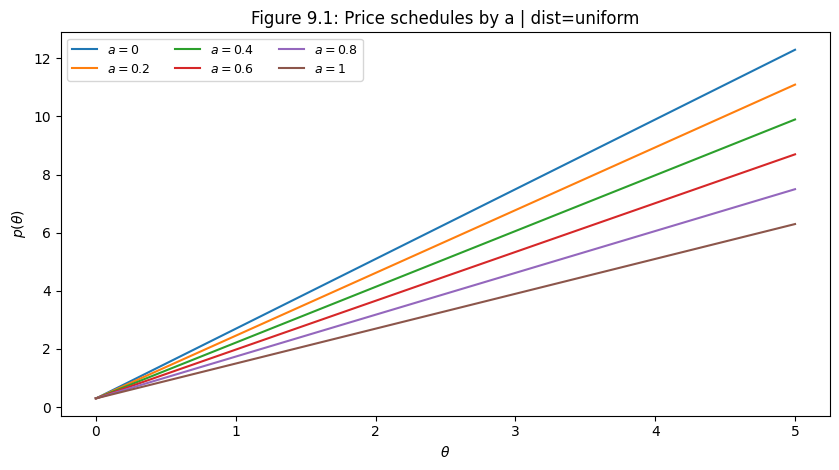

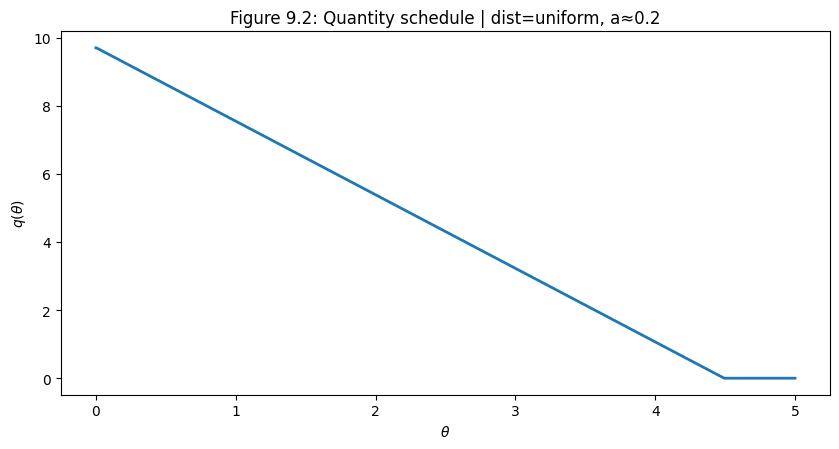

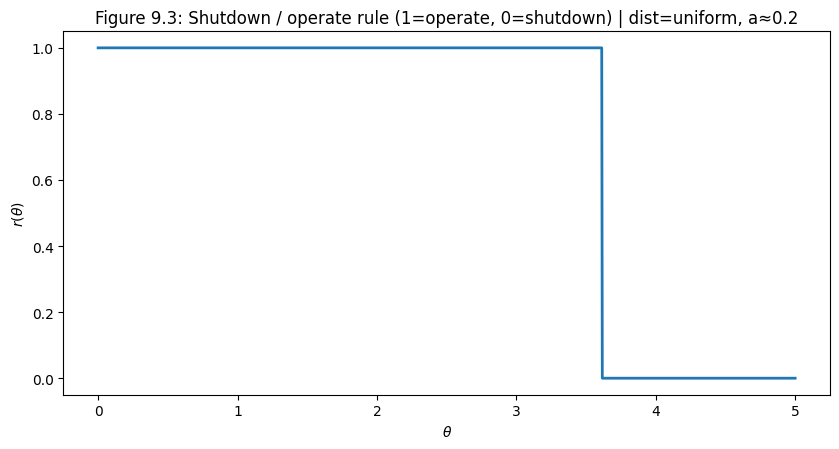

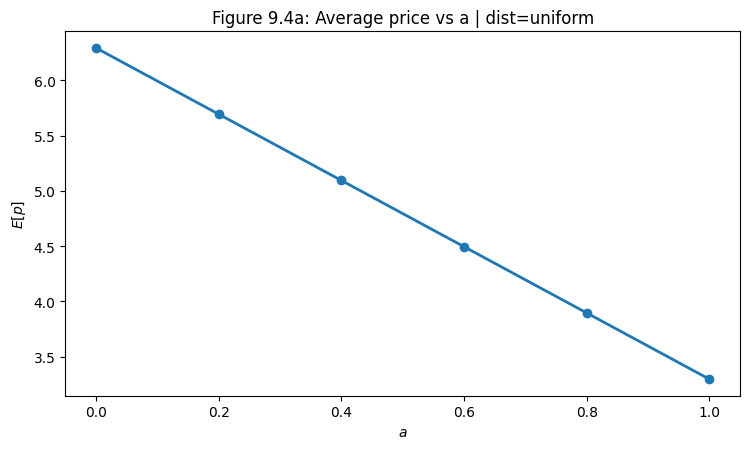

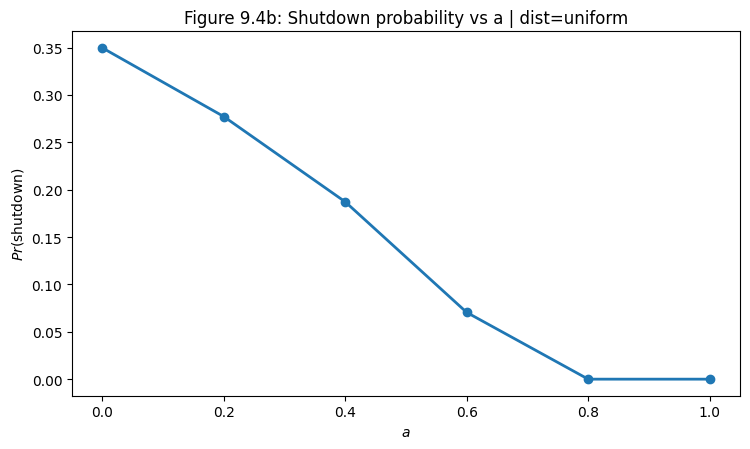

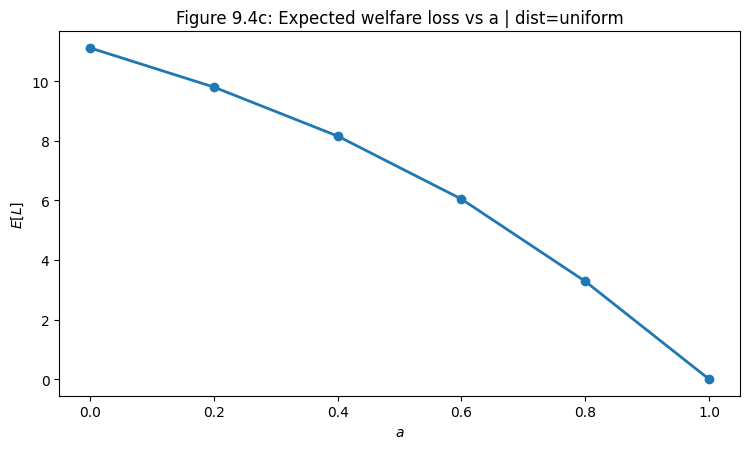

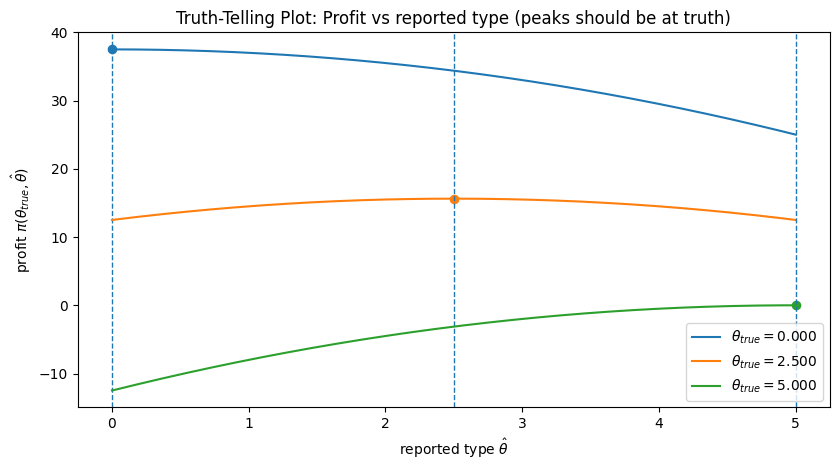

In [12]:
# =========================================================
# Step 9 — Figures (Replication results)
# =========================================================

# ---------- Plot helpers (robust to float grids / missing filters) ----------

def available_a(df, dist_name=None):
    """Return sorted unique a values (optionally for one distribution)."""
    if dist_name is None:
        vals = df["a"].unique()
    else:
        vals = df.loc[df["dist"] == dist_name, "a"].unique()
    return np.sort(vals.astype(float))


def pick_nearest_a(df, a_target, dist_name=None):
    """
    Pick the nearest a that actually exists in df (optionally within one dist).
    Avoids empty plots when df has a={0,0.2,0.4,...} but you ask for 0.25.
    """
    a_vals = available_a(df, dist_name=dist_name)
    if len(a_vals) == 0:
        raise ValueError("No 'a' values found in df for the requested filter.")
    j = int(np.argmin(np.abs(a_vals - float(a_target))))
    return float(a_vals[j])


def subset_run(df, dist_name, a_target):
    """
    Return a non-empty subset for (dist, a). If (dist, a_target) doesn't exist,
    snap to the nearest available a.
    """
    a_used = pick_nearest_a(df, a_target, dist_name=dist_name)
    sub = df[(df["dist"] == dist_name) & (np.isclose(df["a"], a_used))]
    if sub.empty:
        raise ValueError(
            f"Empty subset for dist={dist_name}. "
            f"Available dist: {df['dist'].unique()}, available a: {available_a(df, dist_name)}"
        )
    return sub, a_used


# ---------- Figure 9.1: price schedules p(theta) for several a ----------

def fig_price_schedules(df, dist_name="uniform", a_list=None):
    if a_list is None:
        a_list = available_a(df, dist_name=dist_name)

    plt.figure(figsize=(8.5, 4.8))
    for a_target in a_list:
        sub, a_used = subset_run(df, dist_name, a_target)
        th = sub["theta"].to_numpy()
        p = sub["p"].to_numpy()
        plt.plot(th, p, label=fr"$a={a_used:g}$")

    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$p(\theta)$")
    plt.title(f"Figure 9.1: Price schedules by a | dist={dist_name}")
    plt.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    plt.show()


# ---------- Figure 9.2: quantity schedule q(theta) ----------

def fig_quantity_schedule(df, dist_name="uniform", a_target=0.2):
    sub, a_used = subset_run(df, dist_name, a_target)
    th = sub["theta"].to_numpy()
    q = sub["q"].to_numpy()

    plt.figure(figsize=(8.5, 4.6))
    plt.plot(th, q, linewidth=2)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$q(\theta)$")
    plt.title(f"Figure 9.2: Quantity schedule | dist={dist_name}, a≈{a_used:g}")
    plt.tight_layout()
    plt.show()


# ---------- Figure 9.3: shutdown rule r(theta) ----------

def fig_shutdown_rule(df, dist_name="uniform", a_target=0.2):
    sub, a_used = subset_run(df, dist_name, a_target)
    th = sub["theta"].to_numpy()
    r = sub["r"].to_numpy()

    plt.figure(figsize=(8.5, 4.6))
    plt.plot(th, r, linewidth=2)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$r(\theta)$")
    plt.title(f"Figure 9.3: Shutdown / operate rule (1=operate, 0=shutdown) | dist={dist_name}, a≈{a_used:g}")
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.show()


# ---------- Run-level table (one row per (dist,a)) ----------

def run_level_table(df, dist_name):
    """One row per (dist,a): take first row in each group (run-level cols are repeated)."""
    return (
        df[df["dist"] == dist_name]
        .groupby(["dist", "a"], as_index=False)
        .first()
        .sort_values("a")
    )


# ---------- Figure 9.4: aggregates vs a (keep only core replication aggregates) ----------

def fig_aggregate(df, dist_name, ycol, ylabel=None, title=None):
    grp = run_level_table(df, dist_name)
    if ycol not in grp.columns:
        raise ValueError(f"Column '{ycol}' not found. Available columns: {list(grp.columns)}")

    plt.figure(figsize=(7.6, 4.6))
    plt.plot(grp["a"], grp[ycol], marker="o", linewidth=2)
    plt.xlabel(r"$a$")
    plt.ylabel(ylabel if ylabel is not None else ycol)
    plt.title(title if title is not None else f"{ycol} vs a | dist={dist_name}")
    plt.tight_layout()
    plt.show()


def fig_all_aggregates_replication(df, dist_name="uniform"):
    # Average price vs a
    fig_aggregate(df, dist_name, "E_p",
                  ylabel=r"$E[p]$",
                  title=f"Figure 9.4a: Average price vs a | dist={dist_name}")

    # Shutdown probability vs a
    fig_aggregate(df, dist_name, "Pr_shutdown",
                  ylabel=r"$Pr(\text{shutdown})$",
                  title=f"Figure 9.4b: Shutdown probability vs a | dist={dist_name}")

    # Expected welfare loss vs a (if available)
    if "E_welfare_loss" in df.columns:
        fig_aggregate(df, dist_name, "E_welfare_loss",
                      ylabel=r"$E[L]$",
                      title=f"Figure 9.4c: Expected welfare loss vs a | dist={dist_name}")


def truth_telling_profit_plot_from_matrix(policy, theta_grid=None, cost_params=None, true_types=None, title=None):
    r"""
    LaTeX (raw):
        \pi(\theta,\hat\theta)
        =
        \left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta)q(\hat\theta) - (k_0+k_1\theta)\right) r(\hat\theta)
        + s(\hat\theta)

    Visual diagnostic:
        For each chosen true type θ_true, plot π(θ_true, \hatθ) over \hatθ on the report grid.
        Under IC, the curve peaks at \hatθ ≈ θ_true.
    """
    # --- Default to policy metadata (prevents Step 6 vs Step 8 mixups) ---
    if theta_grid is None:
        if "theta_grid" not in policy:
            raise ValueError("theta_grid not provided and policy has no 'theta_grid' metadata.")
        theta_grid = policy["theta_grid"]

    if cost_params is None:
        if "cost_params" not in policy:
            raise ValueError("cost_params not provided and policy has no 'cost_params' metadata.")
        cost_params = policy["cost_params"]

    theta_grid = np.asarray(theta_grid, dtype=float)

    # --- Sanity check: report grid length must match policy arrays ---
    n_reports = len(policy["p"])
    if len(theta_grid) != n_reports:
        raise ValueError(
            f"theta_grid length ({len(theta_grid)}) does not match policy report dimension ({n_reports}). "
            "Use the same theta_grid used to compute the policy (policy['theta_grid'])."
        )

    theta0, theta1 = float(theta_grid.min()), float(theta_grid.max())

    # Default true types: low, mid, high
    if true_types is None:
        theta_mid = 0.5 * (theta0 + theta1)
        true_types = np.array([theta0, theta_mid, theta1], dtype=float)
    else:
        true_types = np.array(true_types, dtype=float)

    Pi = profit_matrix_true_report(true_types, policy, cost_params=cost_params)

    plt.figure(figsize=(8.5, 4.8))
    for i, theta_true in enumerate(true_types):
        prof = Pi[i, :]

        j_star = int(np.argmax(prof))
        theta_star = theta_grid[j_star]
        prof_star = prof[j_star]

        j_truth = int(np.argmin(np.abs(theta_grid - theta_true)))
        theta_truth = theta_grid[j_truth]

        plt.plot(theta_grid, prof, label=fr"$\theta_{{true}}={theta_true:.3f}$")
        plt.scatter([theta_star], [prof_star], s=35)
        plt.axvline(theta_truth, linestyle="--", linewidth=1)

    t = title if title is not None else "Truth-Telling Plot: Profit vs reported type (peaks should be at truth)"
    if "tag" in policy:
        t = t + f" | policy={policy['tag']}"
    plt.title(t)

    plt.xlabel(r"reported type $\hat{\theta}$")
    plt.ylabel(r"profit $\pi(\theta_{true},\hat{\theta})$")
    plt.legend()
    plt.tight_layout()
    plt.show()



# ---------- Suggested figure calls (Step 9) ----------

print("Available dist:", df["dist"].unique())
print("Available a:", np.sort(df["a"].unique()))

# 9.1 price schedules for all simulated a
fig_price_schedules(df, dist_name="uniform")

# 9.2 quantity schedule at representative a (snaps to nearest available a)
fig_quantity_schedule(df, dist_name="uniform", a_target=0.2)

# 9.3 shutdown rule at representative a
fig_shutdown_rule(df, dist_name="uniform", a_target=0.2)

# 9.4 core aggregates vs a
fig_all_aggregates_replication(df, dist_name="uniform")

theta_report_grid = np.linspace(theta_grid.min(), theta_grid.max(), len(out["p"]))

truth_telling_profit_plot_from_matrix(
    policy=out,
    theta_grid=theta_report_grid,
    cost_params=cost_params
)

## 10. Extension: Strong self-financing constraint (subsidies must be funded by taxes)

### Extension question
**How does requiring the mechanism to be self-financing—expected subsidy outflows must be fully funded by expected tax revenues from the firm, with no external financing and no uniform fee—affect:**
1) incentive compatibility (truth-telling),
2) best-response reporting and bunching,
3) realized welfare and shutdown?

### Key idea
In the baseline Baron mechanism, transfers $s(\theta)$ are tightly linked to the allocation rule via the envelope condition.
If a regulator is forced to modify transfers because of a fiscal rule, the mechanism may stop being implementable.

#### Self-financing rule implemented here (minimal-change stress test)
Let $s(\theta)$ be the baseline transfer schedule (positive = subsidy, negative = tax), and define
$$
s^+(\theta)=\max\{s(\theta),0\},\qquad s^-(\theta)=\min\{s(\theta),0\}.
$$

We impose the strong constraint:
$$
\mathbb{E}[\tilde s^+(\theta)] = \mathbb{E}[-\tilde s^-(\theta)],
$$
without any extra fee or outside financing.

Operationally, we **keep taxes unchanged** and **scale down only subsidies**:
$$
\tilde s(\theta)=
\begin{cases}
\alpha\, s(\theta) & s(\theta)>0,\\
s(\theta) & s(\theta)\le 0,
\end{cases}
\qquad
\alpha=\min\left\{1,\ \frac{\mathbb{E}[-s^-(\theta)]}{\mathbb{E}[s^+(\theta)]}\right\}.
$$

#### What we evaluate
- **IC diagnostics:** deviation gains $\Delta(\theta)$ and the best-response map $\hat\theta(\theta)$
- **Truth-telling profit curves:** $\pi(\theta_{\text{true}},\hat\theta)$ vs $\hat\theta$ (peaks should be at truth under IC)
- **Realized welfare under misreporting:** welfare computed using best-response reports (not assuming truth-telling)
- Comparative statics across $a\in\{0.2,0.4,0.6,0.8,1.0\}$


In [13]:
################# Helpers #################

def expected_positive(x, theta_grid, dist):
    r"""
    LaTeX (raw):
        \mathbb{E}[x^+(\theta)] \;=\; \int \max\{x(\theta),0\} \, f(\theta)\, d\theta
    """
    return expected_value_on_grid(np.maximum(np.asarray(x), 0.0), theta_grid, dist)


def expected_negative_magnitude(x, theta_grid, dist):
    r"""
    LaTeX (raw):
        \mathbb{E}[-x^-(\theta)] \;=\; \int \max\{-x(\theta),0\} \, f(\theta)\, d\theta
    """
    return expected_value_on_grid(np.maximum(-np.asarray(x), 0.0), theta_grid, dist)


def apply_self_financing_constraint(policy, theta_grid, dist):
    r"""
    Implements Step 10b "self-financing" in the strongest sense.

    LaTeX (raw):
        s^+(\theta)=\max\{s(\theta),0\},\quad s^-(\theta)=\min\{s(\theta),0\}
        \\
        \tilde s(\theta)=
        \begin{cases}
        \alpha s(\theta) & s(\theta)>0\\
        s(\theta) & s(\theta)\le 0
        \end{cases}
        \quad\text{with}\quad
        \alpha=\min\left\{1,\frac{\mathbb{E}[-s^-(\theta)]}{\mathbb{E}[s^+(\theta)]}\right\}.

    Notes:
    - We keep the allocation rule (p,q,r) unchanged and only modify transfers.
      This is intentionally a "stress test" of implementability under a fiscal rule.
    """
    s = np.asarray(policy["s"], dtype=float)

    E_out = expected_positive(s, theta_grid, dist)              # expected subsidy outflow
    E_rev = expected_negative_magnitude(s, theta_grid, dist)    # expected tax revenue

    if E_out <= 1e-14:
        alpha = 1.0
        s_new = s.copy()
    else:
        alpha = E_rev / E_out
        alpha = min(alpha, 1.0)  # if alpha>1, the constraint is slack -> keep baseline
        s_new = np.where(s > 0.0, alpha * s, s)

    pol_new = dict(policy)
    pol_new["s"] = s_new
    pol_new["alpha_self_fin"] = float(alpha)
    pol_new["E_out_base"] = float(E_out)
    pol_new["E_rev_base"] = float(E_rev)
    pol_new["E_out_new_truth"] = float(expected_positive(s_new, theta_grid, dist))
    pol_new["E_rev_new_truth"] = float(expected_negative_magnitude(s_new, theta_grid, dist))
    return pol_new


def run_self_financing_extension(
    theta_grid,
    dist,
    a_weight,
    demand_kind,
    demand_params,
    cost_params,
    q_max,
    n_phi=2001
):
    # Baseline optimal mechanism
    base = compute_policy(
        theta_grid=theta_grid,
        dist=dist,
        a=a_weight,
        demand_kind=demand_kind,
        demand_params=demand_params,
        cost_params=cost_params,
        q_max=q_max,
        n_phi=n_phi
    )

    # Apply self-financing constraint
    pol_sf = apply_self_financing_constraint(base, theta_grid, dist)

    # IC diagnostics
    ic_pass_base, df_ic_base, ic_sum_base = check_incentive_compatibility(
        policy=base, theta_grid=theta_grid, cost_params=cost_params, tol=1e-5, use_subgrid=401
    )
    ic_pass_sf, df_ic_sf, ic_sum_sf = check_incentive_compatibility(
        policy=pol_sf, theta_grid=theta_grid, cost_params=cost_params, tol=1e-5, use_subgrid=401
    )

    # Realized outcomes under best response (truthful if IC holds)
    realized_base = realized_outcomes_best_response(base, theta_grid, cost_params)
    realized_sf = realized_outcomes_best_response(pol_sf, theta_grid, cost_params)

    # Welfare under realized reporting (same welfare accounting as before)
    W_theta_base, E_W_base, Pr_shut_base = welfare_from_realized(
        theta_grid, realized_base, dist, a_weight, demand_kind, demand_params, cost_params
    )
    W_theta_sf, E_W_sf, Pr_shut_sf = welfare_from_realized(
        theta_grid, realized_sf, dist, a_weight, demand_kind, demand_params, cost_params
    )

    # CI benchmark welfare for "loss" comparison
    # Use your existing helper to compute E[W_CI]
    W_ai_tmp, W_ci_tmp, L_tmp = welfare_contribution(
        theta_grid=theta_grid,
        out_policy=base,
        dist=dist,
        a=a_weight,
        demand_kind=demand_kind,
        demand_params=demand_params,
        cost_params=cost_params
    )
    E_W_CI = expected_value_on_grid(W_ci_tmp, theta_grid, dist)

    summary = pd.DataFrame([{
        "a": float(a_weight),
        "alpha_self_fin": float(pol_sf["alpha_self_fin"]),
        "E_out_base": float(pol_sf["E_out_base"]),
        "E_rev_base": float(pol_sf["E_rev_base"]),
        "E_out_new_truth": float(pol_sf["E_out_new_truth"]),
        "E_rev_new_truth": float(pol_sf["E_rev_new_truth"]),
        "IC_pass_base": bool(ic_sum_base["IC_pass"]),
        "IC_pass_self_fin": bool(ic_sum_sf["IC_pass"]),
        "IC_max_gain_self_fin": float(ic_sum_sf["IC_max_gain"]),
        "IC_share_positive_gain_self_fin": float(ic_sum_sf["IC_share_positive_gain"]),
        "E_W_CI": float(E_W_CI),
        "E_W_realized_base": float(E_W_base),
        "E_W_realized_self_fin": float(E_W_sf),
        "Loss_CI_minus_realized_base": float(E_W_CI - E_W_base),
        "Loss_CI_minus_realized_self_fin": float(E_W_CI - E_W_sf),
        "Pr_shutdown_realized_base": float(Pr_shut_base),
        "Pr_shutdown_realized_self_fin": float(Pr_shut_sf),
    }])

    return base, pol_sf, df_ic_base, df_ic_sf, summary


def profit_matrix_true_report(theta_true_grid, policy, cost_params):
    r"""
    LaTeX (raw):
        \pi(\theta,\hat\theta)
        =
        \left(p(\hat\theta)q(\hat\theta) - (c_0+c_1\theta)q(\hat\theta) - (k_0+k_1\theta)\right) r(\hat\theta)
        + s(\hat\theta)

    Returns:
        Pi: matrix (n_true, n_report)
            rows = true theta, cols = reported theta
    """
    c0, c1, k0, k1 = cost_params

    # report-indexed arrays (policy grid)
    p = np.asarray(policy["p"], dtype=float)
    q = np.asarray(policy["q"], dtype=float)
    r = np.asarray(policy["r"], dtype=float)
    s = np.asarray(policy["s"], dtype=float)

    theta_true = np.asarray(theta_true_grid, dtype=float).reshape(-1, 1)  # (n_true, 1)

    Pi = (p * q - (c0 + c1 * theta_true) * q - (k0 + k1 * theta_true)) * r + s
    return Pi


def realized_outcomes_best_response(policy, theta_grid, cost_params):
    r"""
    LaTeX (raw):
        BR(\theta_i) = \arg\max_{\hat\theta_j} \pi(\theta_i,\hat\theta_j)

        p^{real}(\theta_i)=p(\hat\theta_{BR(i)}),\;
        q^{real}(\theta_i)=q(\hat\theta_{BR(i)}),\;
        r^{real}(\theta_i)=r(\hat\theta_{BR(i)}),\;
        s^{real}(\theta_i)=s(\hat\theta_{BR(i)}).

    Returns:
        dict with realized allocations and best-report mapping on the same grid.
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    n = len(theta_grid)

    Pi = profit_matrix_true_report(theta_grid, policy, cost_params)  # (n_true=n, n_report=n)

    best_j = np.argmax(Pi, axis=1)
    theta_hat = theta_grid[best_j]

    p_real = np.asarray(policy["p"], dtype=float)[best_j]
    q_real = np.asarray(policy["q"], dtype=float)[best_j]
    r_real = np.asarray(policy["r"], dtype=float)[best_j]
    s_real = np.asarray(policy["s"], dtype=float)[best_j]

    pi_real = Pi[np.arange(n), best_j]

    return {
        "theta_true": theta_grid,
        "theta_report": theta_hat,
        "best_j": best_j,
        "p_real": p_real,
        "q_real": q_real,
        "r_real": r_real,
        "s_real": s_real,
        "pi_real": pi_real
    }

def welfare_from_realized(theta_grid, realized, dist, a, demand_kind, demand_params, cost_params):
    r"""
    LaTeX (raw):
        W(\theta)=\left(V(q)-C(q,\theta)\right) r - (1-a)\,\pi(\theta)
    Here:
        q,r,\pi are "realized" under best-response reporting,
        but costs use the true type \theta.
    Returns:
        W_theta : array over theta_grid
        E_W     : expected welfare
        Pr_shutdown : expected shutdown probability (E[1-r])
    """
    theta_grid = np.asarray(theta_grid, dtype=float)
    c0, c1, k0, k1 = cost_params

    # Pick the appropriate V(q)
    if demand_kind == "linear":
        A, B = demand_params
        V_func = V_linear
        V_args = (A, B)
    elif demand_kind == "isoelastic":
        A, eps = demand_params
        V_func = V_isoelastic
        V_args = (A, eps)
    else:
        raise ValueError("Unknown demand_kind. Use 'linear' or 'isoelastic'.")

    q = np.asarray(realized["q_real"], dtype=float)
    r = np.asarray(realized["r_real"], dtype=float)
    pi = np.asarray(realized["pi_real"], dtype=float)

    gross_surplus = (V_func(q, *V_args) - cost(q, theta_grid, c0, c1, k0, k1)) * r
    W_theta = gross_surplus - (1.0 - float(a)) * pi

    E_W = expected_value_on_grid(W_theta, theta_grid, dist)
    Pr_shutdown = expected_value_on_grid(1.0 - r, theta_grid, dist)

    return W_theta, E_W, Pr_shutdown







In [14]:
# -----------------------------
# Step 10 setup (same primitives and parameters as the replication simulations)
# -----------------------------
theta_grid = np.linspace(0.0, 5.0, 1201)
dist = DistUniform(0.0, 5.0)

# Linear demand: q = a_lin - b_lin p  -> inverse demand P(q) = A - B q
a_lin, b_lin = 10.0, 1.0
A, B = a_lin / b_lin, 1.0 / b_lin
demand_kind = "linear"
demand_params = (A, B)

# Costs (same as in Step 8/9 simulation block)
cost_params = (0.3, 1.2, 0.5, 0.2)

# We'll use a=0.2 for the "best figures" diagnostics (then we sweep over a)
a_focus = 0.2

base_focus, pol_sf_focus, df_ic_base_focus, df_ic_sf_focus, summary_focus = run_self_financing_extension(
    theta_grid=theta_grid,
    dist=dist,
    a_weight=a_focus,
    demand_kind=demand_kind,
    demand_params=demand_params,
    cost_params=cost_params,
    q_max=a_lin,
    n_phi=2001
)

summary_focus


/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_27327/103452127.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))


,a,alpha_self_fin,E_out_base,E_rev_base,E_out_new_truth,E_rev_new_truth,IC_pass_base,IC_pass_self_fin,IC_max_gain_self_fin,IC_share_positive_gain_self_fin,E_W_CI,E_W_realized_base,E_W_realized_self_fin,Loss_CI_minus_realized_base,Loss_CI_minus_realized_self_fin,Pr_shutdown_realized_base,Pr_shutdown_realized_self_fin
0,0.2,0.425453,4.034229,1.716376,1.716376,1.716376,True,False,11.149688,0.351621,22.945002,13.148042,12.311054,9.79696,10.633948,0.277083,0.277083


In [15]:
# -----------------------------
# Step 10b: sweep over a and store a comparison table
# -----------------------------
a_list = [0.2, 0.4, 0.6, 0.8, 1.0]

summaries = []
for a_weight in a_list:
    _, _, _, _, summary_sf = run_self_financing_extension(
        theta_grid=theta_grid,
        dist=dist,
        a_weight=a_weight,
        demand_kind=demand_kind,
        demand_params=demand_params,
        cost_params=cost_params,
        q_max=a_lin,
        n_phi=2001
    )
    summaries.append(summary_sf)

summary_all = pd.concat(summaries, ignore_index=True).sort_values("a")
summary_all


/var/folders/st/bz5bk1gj2yxggjsj2kdx8c180000gn/T/ipykernel_27327/103452127.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(x * f, theta_grid))


,a,alpha_self_fin,E_out_base,E_rev_base,E_out_new_truth,E_rev_new_truth,IC_pass_base,IC_pass_self_fin,IC_max_gain_self_fin,IC_share_positive_gain_self_fin,E_W_CI,E_W_realized_base,E_W_realized_self_fin,Loss_CI_minus_realized_base,Loss_CI_minus_realized_self_fin,Pr_shutdown_realized_base,Pr_shutdown_realized_self_fin
0,0.2,0.425453,4.034229,1.716376,1.716376,1.716376,True,False,11.149688,0.351621,22.945002,13.148042,12.311054,9.796960,10.633948,0.277083,0.277083
1,0.4,0.201930,5.839216,1.179116,1.179116,1.179116,True,False,17.374658,0.466334,22.945002,14.791553,13.248330,8.153449,9.696672,0.187083,0.187083
2,0.6,0.062735,8.907479,0.558807,0.558807,0.558807,True,False,21.512121,0.648379,22.945002,16.904632,14.068148,6.040370,8.876855,0.070417,0.070417
3,0.8,0.007053,13.384989,0.094399,0.094399,0.094399,True,False,23.270243,0.882793,22.945002,19.664995,15.497211,3.280007,7.447791,0.000000,0.000000
4,1.0,0.000000,18.629089,0.000000,0.000000,0.000000,True,False,23.507948,0.997506,22.945002,22.944998,18.016219,0.000004,4.928783,0.000000,0.000000


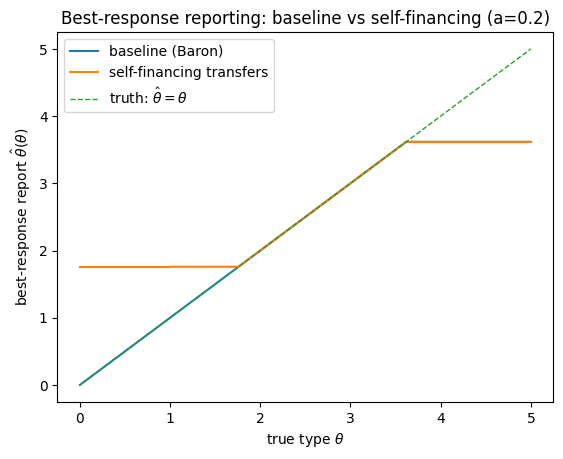

In [16]:
# -----------------------------
# Figure 10.1: Best-response reporting (baseline vs self-financing) at a_focus
# -----------------------------
real_base = realized_outcomes_best_response(base_focus, theta_grid, cost_params)
real_sf = realized_outcomes_best_response(pol_sf_focus, theta_grid, cost_params)

plt.figure()
plt.plot(real_base["theta_true"], real_base["theta_report"], label="baseline (Baron)")
plt.plot(real_sf["theta_true"], real_sf["theta_report"], label="self-financing transfers")
plt.plot(theta_grid, theta_grid, linestyle="--", linewidth=1, label=r"truth: $\hat	\theta=	\theta$")

plt.xlabel(r"true type $\theta$")
plt.ylabel(r"best-response report $\hat{\theta}(\theta)$")
plt.title(fr"Best-response reporting: baseline vs self-financing (a={a_focus})")
plt.legend()
plt.show()


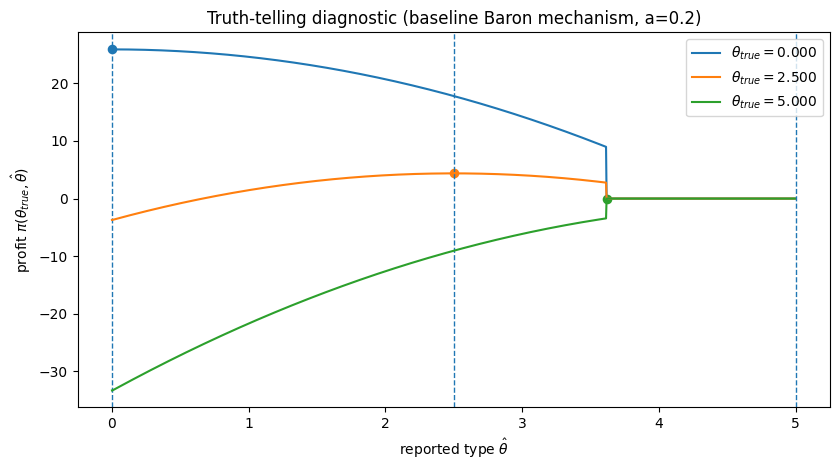

In [17]:
# -----------------------------
# Figure 10.2: Truth-telling profit curves (baseline vs self-financing)
# -----------------------------
# Under IC, each curve should peak at the true type (vertical dashed line).
# Under self-financing, peaks can shift away from truth (profitable misreporting).

truth_telling_profit_plot_from_matrix(
    policy=base_focus,
    theta_grid=theta_grid,
    cost_params=cost_params,
    true_types=[theta_grid.min(), 0.5*(theta_grid.min()+theta_grid.max()), theta_grid.max()],
    title=fr"Truth-telling diagnostic (baseline Baron mechanism, a={a_focus})"
)



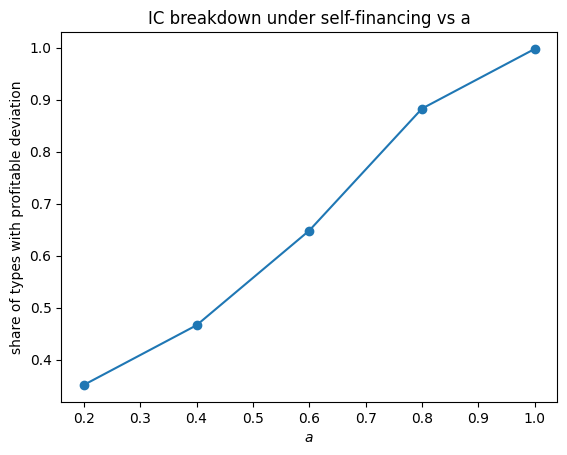

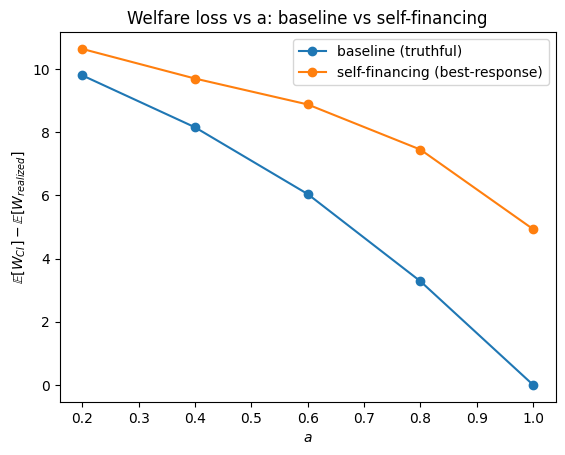

In [18]:
# -----------------------------
# Figures 10.3–10.4: Performance vs a (baseline vs self-financing)
# -----------------------------

# Incentive breakdown: share of types with profitable deviations under self-financing
plt.figure()
plt.plot(summary_all["a"], summary_all["IC_share_positive_gain_self_fin"], marker="o")
plt.xlabel(r"$a$")
plt.ylabel("share of types with profitable deviation")
plt.title("IC breakdown under self-financing vs a")
plt.show()

# Welfare comparison (loss relative to complete information)
plt.figure()
plt.plot(summary_all["a"], summary_all["Loss_CI_minus_realized_base"], marker="o", label="baseline (truthful)")
plt.plot(summary_all["a"], summary_all["Loss_CI_minus_realized_self_fin"], marker="o", label="self-financing (best-response)")
plt.xlabel(r"$a$")
plt.ylabel(r"$\mathbb{E}[W_{CI}] - \mathbb{E}[W_{realized}]$")
plt.title("Welfare loss vs a: baseline vs self-financing")
plt.legend()
plt.show()


### Step 10: Interpretation of the self-financing extension results (based on the figures)

#### What changes when we impose self-financing?
In the baseline Baron mechanism, transfers $s(\theta)$ are chosen to satisfy incentive compatibility via the envelope condition: once the allocation rule $(q(\theta), r(\theta))$ is fixed, the transfer schedule is pinned down (up to a boundary condition) so that truth-telling is optimal.  

In the self-financing extension, we impose the fiscal rule
$$
\mathbb{E}[\tilde s^+(\theta)] = \mathbb{E}[-\tilde s^-(\theta)],
\qquad
\tilde s(\theta)=
\begin{cases}
\alpha\, s(\theta) & s(\theta)>0,\\
s(\theta) & s(\theta)\le 0,
\end{cases}
$$
so positive subsidies must be scaled down to match tax revenues. When \(\alpha<1\), the transfer schedule is no longer consistent with the envelope condition implied by the baseline allocation rule, so the baseline mechanism may no longer be implementable as a truthful (IC) mechanism.

---

#### Figure: Best-response reporting $\hat\theta(\theta)$ (baseline vs self-financing)
The best-response plot shows a sharp contrast between the baseline and the self-financing policy:

- **Baseline:** the best-response mapping $\hat\theta(\theta)$ lies on the 45-degree line ($\hat\theta=\theta$) for essentially all types, confirming that **truth-telling is optimal** (IC holds).
- **Self-financing:** the best-response mapping deviates from the 45-degree line. In particular:
  - **Low types bunch upward** (many low $\theta$ report approximately the same higher $\hat\theta$), indicating pooling/misreporting induced by the fiscal constraint.
  - **High types report near a boundary** (a flat segment at high $\theta$), consistent with the mechanism entering a region where the allocation/profit becomes relatively flat across reports (e.g., shutdown/low-output region and/or indifference across high reports).

This figure provides a direct visual proof that the self-financing constraint can destroy the truthful equilibrium.

---

#### Figure: Truth-telling profit curves $\pi(\theta_{\text{true}}, \hat\theta)$
The “profit vs report” figure (for selected true types) explains *why* misreporting occurs:

- For a **low-cost firm** $(\theta$ low), the profit curve peaks **away from** the truthful report. This means the firm can strictly increase profits by reporting a higher type, matching the bunching seen in the best-response map.
- For a **middle type**, the peak is close to the truthful report, consistent with the region where $\hat\theta(\theta)\approx \theta$.
- For a **high type**, profits often become flat near zero after some report threshold (a plateau). This suggests that once the mechanism assigns shutdown/zero quantity (or otherwise eliminates profitable production), the firm becomes indifferent among a range of high reports, and the numerical best-response selects a boundary report.

Overall, these profit curves confirm that under self-financing the mechanism is no longer incentive compatible: truthful reporting is not globally optimal.

---

#### Welfare and IC Deviations
After allowing firms to best-respond (i.e., report strategically when IC fails), realized welfare under self-financing falls relative to the baseline mechanism. This increases the welfare loss relative to complete information:

$$
\mathbb{E}[W^{CI} - W^{\text{realized}}]
$$
because misreporting causes types to be matched with allocations intended for different reports, generating inefficiency.

The share of types that prefer to misreport **increases strongly with $a$**: it rises from roughly **35% at $a=0.2$** to almost **100% at $a=1$**. In other words, as \(a\) increases, the truthful equilibrium becomes less and less feasible under the self-financing constraint.

**Economic intuition.**  

When $a$ is larger, the baseline Baron mechanism places more weight on firm profits and therefore tends to rely more on **positive transfers (subsidies)** and less on **negative transfers (taxes)**. Under self-financing, subsidies must be funded by taxes, so the required scaling factor $\alpha_{\text{self-fin}}$ becomes very small. This drastically alters the transfer schedule relative to what the envelope condition would require, making truth-telling unattractive for a growing set of types. The figure summarizes this: a tighter self-financing constraint (implied by higher $a$) leads to **widespread incentive compatibility failure**.

---

#### Takeaway
The extension demonstrates an implementability result: the Baron mechanism may require transfer schedules that are not compatible with strong fiscal rules. When subsidies must be fully funded by taxes without external financing, transfers may need to be scaled down substantially, and the resulting mechanism can fail to support truthful reporting. This leads to strategic misreporting, bunching in reports, and lower realized welfare relative to the baseline replication.


# Discussion and conclusion (0.5 points)

The baseline replication behaves as predicted by Baron (1982): once the allocation rule is made monotone (via ironing) and transfers are constructed using the envelope logic, the resulting mechanism is incentive compatible (truth-telling).

Under the self-financing constraint (Step 10b), positive subsidies must be reduced to match available tax revenue. This changes the shape of the transfer schedule and breaks the envelope relationship required for truthful implementation. As a result:
- **IC fails** (large deviation gains for some types and best-response reporting deviates from the 45° line with clear bunching).
- **Realized welfare falls** relative to the baseline once firms are allowed to misreport optimally, increasing the welfare loss relative to complete information.
- The severity of the self-financing constraint varies strongly with \(a\): in my simulations, higher \(a\) implies the baseline mechanism relies more on subsidies and less on taxes, making self-financing especially tight (small \(\alpha\)) and IC violations more severe.

## Weaknesses and possible improvements
1) **Not re-optimizing under the constraint:** The extension applies the fiscal rule to the baseline mechanism rather than solving the fully optimal mechanism with self-financing built into the regulator’s problem. Solving the constrained optimum would be a larger project.
2) **Discretization / numerical approximation:** The mechanism is solved on a finite grid for \(\theta\) and with numerical ironing and optimization. Results can depend (slightly) on grid density and tolerances.
3) **Single firm and one-dimensional type:** The model abstracts from multiple firms, competition, multi-dimensional private information, and dynamic incentives.
4) **Limited institutional detail:** Real-world self-financing may be enforced over time, with borrowing, political constraints, or multi-program budgets. Extending the model to a dynamic budget constraint could be an interesting next step.

Overall, the simulations show that the Baron mechanism can be fragile to realistic fiscal constraints: if the regulator cannot implement the transfer schedule implied by the envelope condition, truth-telling may no longer be feasible and welfare losses can increase substantially.
